In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tifffile as tiff

In [2]:
file_path = 'dataset/annotations0-data0.tif'

# Load the 3D volume
tif = tiff.TiffFile(file_path)
volume = tif.asarray()
metadata = tif.pages[0].tags

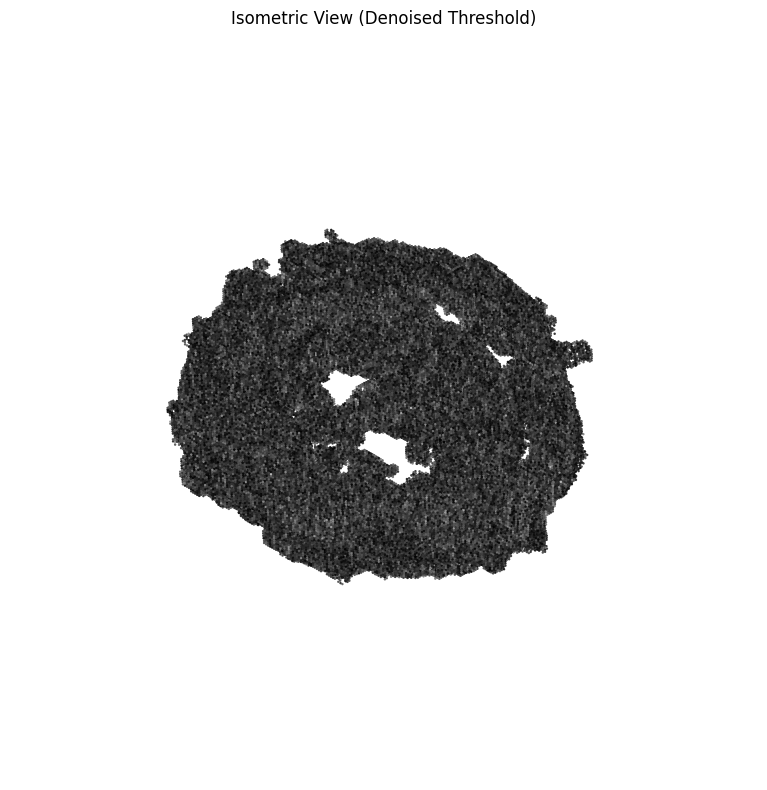

In [ ]:
# Isometric 2D rendering of the 3D volume (no slices)
vol = volume
if vol.ndim == 4 and vol.shape[0] == 1:
    vol = vol[0]
if vol.ndim == 4 and vol.shape[-1] == 1:
    vol = vol[..., 0]

# Treat darker values as structure (background is near 1.0)
low_thresh = np.percentile(vol, 0.9)
mask = vol <= low_thresh

# Remove isolated voxels by requiring local support
z_dim, y_dim, x_dim = mask.shape
padded = np.pad(mask, 1, mode='constant', constant_values=False)
neighbor_count = np.zeros_like(mask, dtype=np.int16)
for dz in (-1, 0, 1):
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dz == 0 and dy == 0 and dx == 0:
                continue
            neighbor_count += padded[1 + dz:1 + dz + z_dim, 1 + dy:1 + dy + y_dim, 1 + dx:1 + dx + x_dim]
mask = mask & (neighbor_count >= 12)

coords = np.argwhere(mask)
values = vol[mask]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(coords[:, 2], coords[:, 1], coords[:, 0], c=values, cmap='gray_r', s=3, alpha=0.8, linewidths=0)

ax.view_init(elev=35.264, azim=45)
ax.set_box_aspect((vol.shape[2], vol.shape[1], vol.shape[0]))
ax.set_title('Isometric View (Denoised Threshold)')
ax.set_axis_off()
plt.tight_layout()
plt.show()